<a href="https://colab.research.google.com/github/SUPRAJ29DB/machine_learning_01/blob/main/edu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded=files.upload()

Saving employee_data_800.csv to employee_data_800.csv


In [3]:
df=pd.read_csv("employee_data_800.csv")

In [4]:
df

,City,Gender,Education,Experience,Age,Salary
0,Delhi,Male,MBA,2,21,High
1,Delhi,Male,BSc,5,23,High
2,Chennai,Male,MBA,4,25,Low
3,Chennai,Male,BSc,1,21,Low
4,Kolkata,Female,BSc,4,30,High
...,...,...,...,...,...,...
795,Chennai,Male,BTech,4,26,Medium
796,Chennai,Female,BTech,6,26,Medium
797,Delhi,Female,BSc,2,22,High
798,Mumbai,Male,BSc,6,27,Low


In [5]:
df.isnull().sum()

,0
City,0
Gender,0
Education,0
Experience,0
Age,0
Salary,0


In [6]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [8]:
X = df.drop('Salary', axis=1)
y = df['Salary']

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(), [0, 1, 2])],
    remainder='passthrough'
)

x = ct.fit_transform(X)

le = LabelEncoder()
y = le.fit_transform(y)

In [9]:
from sklearn  import linear_model
from sklearn.model_selection import train_test_split

In [10]:
x_train,x_test,y_train,y_test=train_test_split=train_test_split(x,y, test_size=0.2, random_state=0)

In [11]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

In [12]:
y_pred=regressor.predict(x_test)

In [13]:
from sklearn import metrics
print("Mean Absolute Error")
print(metrics.mean_absolute_error(y_test,y_pred))
print("mean Squared Error")
print(metrics.mean_squared_error(y_test,y_pred))
print("Root Mean Squared Error")
print(np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

Mean Absolute Error
0.7224653181913986
mean Squared Error
0.7085818279466525
Root Mean Squared Error
0.8417730263833907


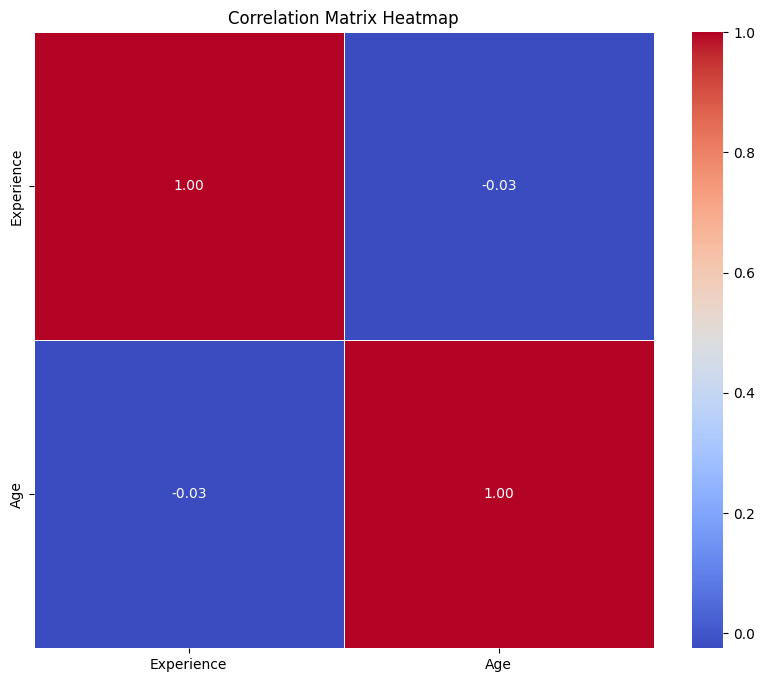

In [16]:
import seaborn as sns

# Select only numerical columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix Heatmap')
plt.show()

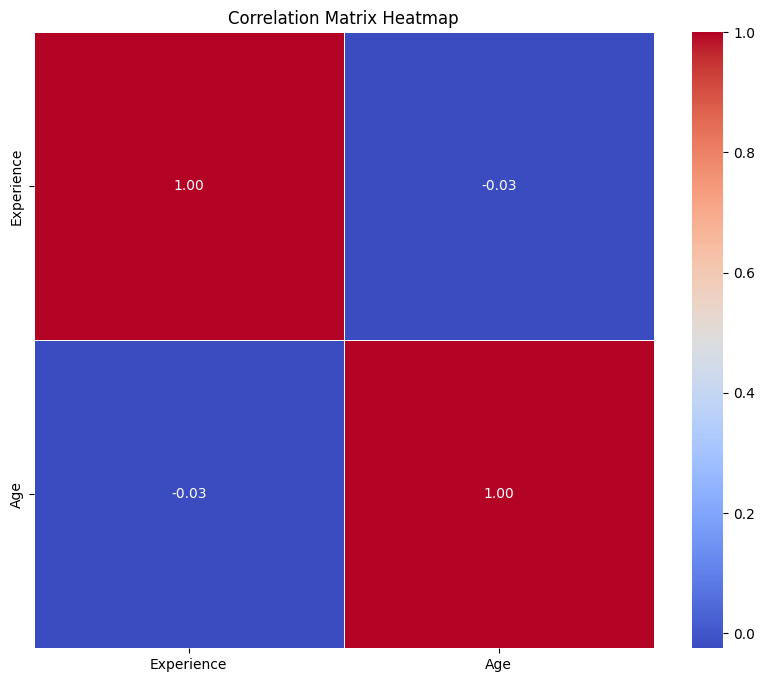

In [18]:
# Select only numerical columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix Heatmap')
plt.show()

<Figure size 800x600 with 0 Axes>

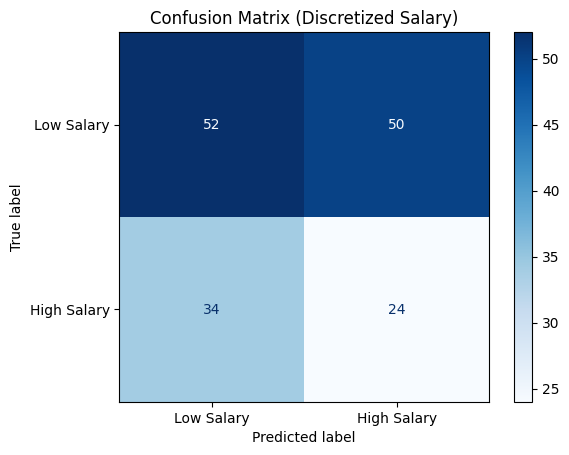

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Since this is regression, we discretize values to create a classification context
threshold = np.median(y_test)
y_test_cat = (y_test > threshold).astype(int)
y_pred_cat = (y_pred > threshold).astype(int)

# Generate confusion matrix
cm = confusion_matrix(y_test_cat, y_pred_cat)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Salary', 'High Salary'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Discretized Salary)')
plt.show()

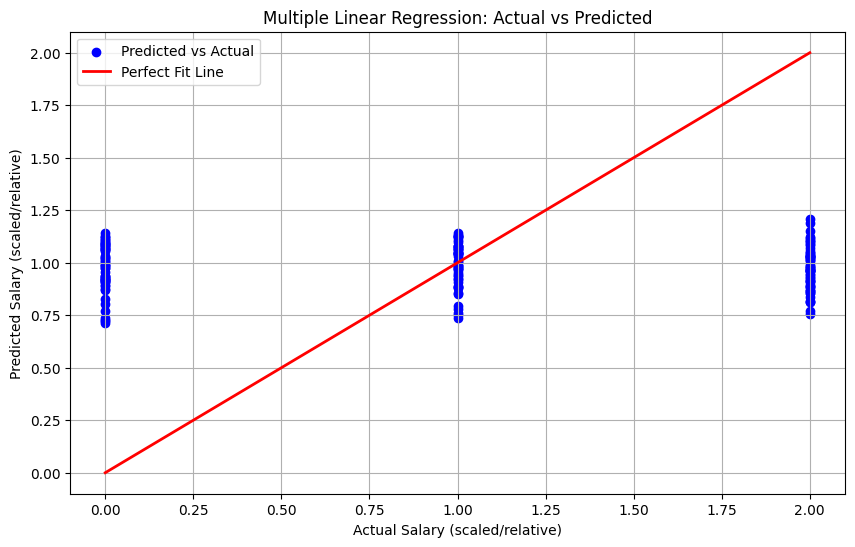

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2, label='Perfect Fit Line')
plt.xlabel('Actual Salary (scaled/relative)')
plt.ylabel('Predicted Salary (scaled/relative)')
plt.title('Multiple Linear Regression: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()